# ART Warm-Starting Summary

This notebook is aligned with the generalized, no-language ART warm-start analysis saved by
[art_warmstarting_analysis.py](/home/yuji/github/art_lang/rpod/rages/art_warmstarting_analysis.py).

It focuses on the summary plots that are still meaningful for the randomized generalized test set:
- cumulative-constraint-violation bin counts
- optimality gap relative to CVX
- SCP iteration counts
- total runtime, including the ART inference-time GPU overlay


In [1]:
import os
import sys
from pathlib import Path

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch


def find_root_path(path: str, word: str):
    parts = path.split(word, 1)
    return parts[0] + word if len(parts) > 1 else None


path_candidates = []
if '__file__' in globals():
    path_candidates.append(os.path.abspath(__file__))
path_candidates.append(os.path.abspath(os.getcwd()))

root_folder = None
for candidate in path_candidates:
    root_folder = find_root_path(candidate, 'art_lang')
    if root_folder is not None:
        break

if root_folder is None:
    raise RuntimeError('Could not locate the art_lang repository root.')

sys.path.append(root_folder)

warmstart_dir = Path(root_folder) / 'rpod' / 'optimization' / 'saved_files' / 'warmstarting'
figures_dir = Path(root_folder) / 'rpod' / 'rages' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)


In [2]:
analysis_stem = 'art_02_generalized_random_test_final'
analysis_path = warmstart_dir / f'ws_analysis_{analysis_stem}.npz'

ws_data = np.load(analysis_path, allow_pickle=True)

cost_scale = 1e3

J_cvx = ws_data['J_cvx'] * cost_scale
J_art = ws_data['J_art'] * cost_scale
J_cvx_scp = ws_data['J_cvx_scp'] * cost_scale
J_art_scp = ws_data['J_art_scp'] * cost_scale

iter_cvx = ws_data['iter_cvx_scp']
iter_art = ws_data['iter_art_scp']

ctgs0_cvx = ws_data['ctgs0_cvx']
ctgs0_art = ws_data['ctgs0_art']

runtime_cvx = ws_data['runtime_cvx']
runtime_art = ws_data['runtime_art']
runtime_cvx_total = ws_data['runtime_cvx'] + ws_data['runtime_cvx_scp']
runtime_art_total = ws_data['runtime_art'] + ws_data['runtime_art_scp']

i_infeas_cvx = ws_data['i_infeas_cvx']
i_infeas_cvx_scp = ws_data['i_infeas_cvx_scp']
i_infeas_art_scp = ws_data['i_infeas_art_scp']

n_time_used = ws_data['n_time_used']
tf_sec = ws_data['tf_sec']
artms_param_1e3 = ws_data['artms_param_1e3']
sample_source = ws_data['sample_source']

n_samples = len(J_cvx)
n_cvx = int(np.isfinite(J_cvx).sum())
n_art = int(np.isfinite(J_art).sum())
n_cvx_scp = int(np.isfinite(J_cvx_scp).sum())
n_art_scp = int(np.isfinite(J_art_scp).sum())

rt_mask = np.isfinite(runtime_art_total) & (runtime_art_total > 0)
inference_share = runtime_art[rt_mask] / runtime_art_total[rt_mask]

print(f'Loaded: {analysis_path}')
print(f'Samples: {n_samples}')
print(f'Feasible CVX: {n_cvx}/{n_samples}')
print(f'Feasible ART warm-start: {n_art}/{n_samples}')
print(f'Feasible CVX-SCP: {n_cvx_scp}/{n_samples}')
print(f'Feasible ART-SCP: {n_art_scp}/{n_samples}')
print(f'Unique sample sources: {np.unique(sample_source)}')
if inference_share.size:
    print(f'Median ART inference share of ART total runtime: {np.nanmedian(inference_share):.3f}')
    print(f'Mean ART inference share of ART total runtime: {np.nanmean(inference_share):.3f}')
print(f'n_time range: {np.nanmin(n_time_used):.0f} to {np.nanmax(n_time_used):.0f}')
print(f'tf range [hr]: {np.nanmin(tf_sec)/3600:.2f} to {np.nanmax(tf_sec)/3600:.2f}')
print(f'artms_param_1e3 values: {np.unique(np.round(artms_param_1e3, 3))}')


Loaded: /home/yuji/github/art_lang/rpod/optimization/saved_files/warmstarting/ws_analysis_art_02_generalized_random_test_final.npz
Samples: 1000
Feasible CVX: 1000/1000
Feasible ART warm-start: 1000/1000
Feasible CVX-SCP: 518/1000
Feasible ART-SCP: 558/1000
Unique sample sources: ['random']
Median ART inference share of ART total runtime: 0.079
Mean ART inference share of ART total runtime: 0.094
n_time range: 5 to 45
tf range [hr]: 0.62 to 6.87
artms_param_1e3 values: [0.75 1.   1.25 1.5  2.  ]


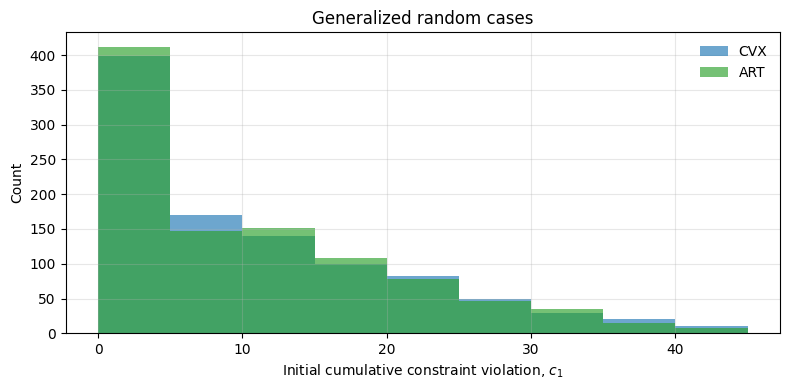

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))

ctg_mask_cvx = np.isfinite(ctgs0_cvx)
ctg_mask_art = np.isfinite(ctgs0_art)
max_ctg = int(max(np.nanmax(ctgs0_cvx[ctg_mask_cvx]), np.nanmax(ctgs0_art[ctg_mask_art])))
bins = np.arange(0, max(5, max_ctg + 5), 5)

ax.hist(ctgs0_cvx[ctg_mask_cvx], bins=bins, alpha=0.65, label='CVX', color='tab:blue')
ax.hist(ctgs0_art[ctg_mask_art], bins=bins, alpha=0.65, label='ART', color='tab:green')
ax.set_xlabel(r'Initial cumulative constraint violation, $c_1$')
ax.set_ylabel('Count')
ax.set_title('Generalized random cases')
ax.legend(frameon=False)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(figures_dir / 'art_ws_ctg_hist.png', dpi=300)
plt.show()


In [4]:
def to_mask(idx, n):
    mask = np.zeros(n, dtype=bool)
    arr = np.asarray(idx).ravel()
    if arr.size:
        arr = arr.astype(int)
        arr = arr[(arr >= 0) & (arr < n)]
        mask[arr] = True
    return mask


def auto_ctg_max(ctgs0, step=5, min_max=25):
    ctgs0 = np.asarray(ctgs0, dtype=float)
    pos = ctgs0[np.isfinite(ctgs0) & (ctgs0 > 0)]
    if pos.size == 0:
        return min_max
    return max(min_max, int(step * np.ceil(np.percentile(pos, 95) / step)))


def make_bins(ctgs0, ctg_min=1, ctg_max=45, step=5):
    n = int((ctg_max - ctg_min + 1) / step)
    edges_core = np.linspace(ctg_min, ctg_max, num=n + 1)
    bin_ids_core = np.clip(
        np.digitize(ctgs0, edges_core, right=False) - 1,
        0,
        len(edges_core) - 2,
    )

    bin_ids_final = bin_ids_core + 1
    ps_mask = np.isclose(ctgs0, 0.0)
    bin_ids_final[ps_mask] = 0

    labels_core = [
        f"{int(edges_core[i])}-{int(edges_core[i + 1])}"
        for i in range(len(edges_core) - 1)
    ]
    labels_full = ['0'] + labels_core
    return bin_ids_final, labels_full, edges_core


def counts_by_bin(mask, bin_ids, n_bins):
    if not np.any(mask):
        return np.zeros(n_bins, dtype=int)
    return np.bincount(bin_ids[mask], minlength=n_bins).astype(int)


def half_violin(ax, data_list, positions, width, side, color, alpha, mean='center'):
    if not data_list:
        return

    v = ax.violinplot(
        data_list,
        positions=positions,
        widths=width,
        showmeans=False,
        showextrema=False,
    )

    for body, p in zip(v['bodies'], positions):
        verts = body.get_paths()[0].vertices
        if side == 'left':
            verts[verts[:, 0] > p, 0] = p
        elif side == 'right':
            verts[verts[:, 0] < p, 0] = p
        body.set_facecolor(color)
        body.set_alpha(alpha)
        body.set_edgecolor('none')

    for d, p in zip(data_list, positions):
        if len(d) == 0:
            continue
        m = float(np.mean(d))
        if mean == 'left':
            ax.plot([p - 0.15, p - 0.02], [m, m], lw=2, color=color)
        elif mean == 'right':
            ax.plot([p + 0.02, p + 0.15], [m, m], lw=2, color=color)
        else:
            ax.plot([p - 0.12, p + 0.12], [m, m], lw=2, color=color)


def prune_empty(datasets, positions):
    data_ok, pos_ok = [], []
    for d, p in zip(datasets, positions):
        arr = np.asarray(d).ravel()
        arr = arr[np.isfinite(arr)]
        if arr.size:
            data_ok.append(arr.astype(float))
            pos_ok.append(p)
    return data_ok, pos_ok


def per_bin_arrays(values, ctgs0, edges_core, keep_idx_set):
    values = np.asarray(values, dtype=float)
    out = []
    for i in range(len(edges_core) - 1):
        lo, hi = edges_core[i], edges_core[i + 1]
        idx = np.where((ctgs0 >= lo) & (ctgs0 < hi))[0]
        if keep_idx_set is not None:
            idx = [j for j in idx if j in keep_idx_set]
        arr = values[idx]
        out.append(arr[np.isfinite(arr)].ravel())
    return out


def plot_metric_half_violins(
    ax,
    bin_ids,
    n_bins,
    m_domain,
    mask,
    vals_left,
    vals_right,
    color_left,
    color_right,
    alpha_left,
    alpha_right,
):
    data_left, data_right, pos_left, pos_right = [], [], [], []
    vals_left = np.asarray(vals_left, dtype=float)
    vals_right = np.asarray(vals_right, dtype=float)
    for b in range(1, n_bins):
        in_bin = (bin_ids == b) & m_domain
        v_left = vals_left[in_bin & mask]
        v_right = vals_right[in_bin & mask]
        v_left = v_left[np.isfinite(v_left)]
        v_right = v_right[np.isfinite(v_right)]
        if v_left.size:
            data_left.append(v_left)
            pos_left.append(b)
        if v_right.size:
            data_right.append(v_right)
            pos_right.append(b)

    if data_left:
        half_violin(ax, data_left, pos_left, width=0.8, side='left', color=color_left, alpha=alpha_left, mean='left')
    if data_right:
        half_violin(ax, data_right, pos_right, width=0.8, side='right', color=color_right, alpha=alpha_right, mean='right')
    plt.setp(ax.collections, alpha=0.3)


def plot_cvx_art_summary(
    J_cvx,
    J_art,
    J_cvx_scp,
    J_art_scp,
    ctgs0,
    i_infeas_cvx,
    i_infeas_cvx_scp,
    i_infeas_art_scp,
    iter_cvx,
    iter_art,
    runtime_cvx_total,
    runtime_art_total,
    runtime_art_inf,
    ctg_min=1,
    ctg_max=None,
    step=5,
):
    n = len(J_cvx)
    if ctg_max is None:
        ctg_max = auto_ctg_max(ctgs0, step=step)

    m_cvx_infeas = to_mask(i_infeas_cvx, n)
    m_cvx_scp_infeas = to_mask(i_infeas_cvx_scp, n)
    m_art_scp_infeas = to_mask(i_infeas_art_scp, n)

    m_domain = (~m_cvx_infeas) & np.isfinite(ctgs0)
    m_ps = np.isclose(ctgs0, 0.0)
    m_nonps = m_domain & (~m_ps)

    bin_ids, labels_full, edges_core = make_bins(ctgs0, ctg_min=ctg_min, ctg_max=ctg_max, step=step)
    n_bins = len(labels_full)
    x = np.arange(n_bins)

    colors = {
        'ps': '0.55',
        'cvx_scp': 'tab:blue',
        'cvx_fail': 'tab:red',
        'art': 'tab:green',
        'art_scp': 'tab:orange',
    }

    ps_counts = counts_by_bin(m_domain & m_ps, bin_ids, n_bins)
    cvx_conv = m_nonps & (~m_cvx_scp_infeas)
    art_conv = m_nonps & (~m_art_scp_infeas)
    cvx_inf = m_nonps & m_cvx_scp_infeas
    art_inf = m_nonps & m_art_scp_infeas

    cvx_conv_cnt = counts_by_bin(cvx_conv, bin_ids, n_bins)
    art_conv_cnt = counts_by_bin(art_conv, bin_ids, n_bins)
    cvx_inf_cnt = counts_by_bin(cvx_inf, bin_ids, n_bins)
    art_inf_cnt = counts_by_bin(art_inf, bin_ids, n_bins)

    w, dx = 0.40, 0.20
    x_cvx, x_art = x - dx, x + dx

    fig = plt.figure(figsize=(11, 5))
    gs = gridspec.GridSpec(2, 2, figure=fig, width_ratios=[1, 1])
    ax_stack = fig.add_subplot(gs[0, 0])
    ax_gap = fig.add_subplot(gs[0, 1])
    ax_iter = fig.add_subplot(gs[1, 0])
    ax_runtime = fig.add_subplot(gs[1, 1])
    rot = 45

    if n_bins > 0:
        ax_stack.bar(x_cvx[0], ps_counts[0], width=w, color=colors['ps'], alpha=0.95, label='Passive-safe')
        ax_stack.bar(x_art[0], ps_counts[0], width=w, color=colors['ps'], alpha=0.95)

    sl = slice(1, None)
    ax_stack.bar(x_cvx[sl], cvx_conv_cnt[sl], width=w, color=colors['cvx_scp'], alpha=0.80, label='CVX-SCP converged')
    ax_stack.bar(x_cvx[sl], cvx_inf_cnt[sl], width=w, bottom=cvx_conv_cnt[sl], color=colors['cvx_fail'], alpha=0.95, label='CVX-SCP infeasible')
    ax_stack.bar(x_art[sl], art_conv_cnt[sl], width=w, color=colors['art_scp'], alpha=0.80, label='ART-SCP converged')
    ax_stack.bar(x_art[sl], art_inf_cnt[sl], width=w, bottom=art_conv_cnt[sl], color=colors['cvx_fail'], alpha=0.45, label='ART-SCP infeasible')

    nonps_total = np.maximum(cvx_conv_cnt + cvx_inf_cnt, art_conv_cnt + art_inf_cnt)
    y_max = max(nonps_total.max() if nonps_total.size else 0, ps_counts[0] if ps_counts.size else 0)
    y_off = 0.01 * (y_max if y_max > 0 else 1.0)
    for b in range(1, n_bins):
        if art_conv_cnt[b] or cvx_conv_cnt[b]:
            ax_stack.text(
                x[b],
                nonps_total[b] + y_off,
                f"Δ={int(art_conv_cnt[b] - cvx_conv_cnt[b]):+d}",
                ha='center',
                va='bottom',
                fontsize=8,
            )

    ax_stack.set_xticks(x)
    ax_stack.set_xticklabels(labels_full, rotation=rot)
    ax_stack.set_xlabel(r'Cumulative constraint violation (CVX), $c_1$')
    ax_stack.set_ylabel('Count')
    ax_stack.legend(loc='upper right', fontsize=7.5)
    ax_stack.set_title('Convergence by CVX $c_1$ bin')
    ymin, ymax = ax_stack.get_ylim()
    ax_stack.set_ylim(0, ymax + 0.12 * max(ymax - ymin, 1.0))

    feas_idx = set(np.where(
        (~m_cvx_scp_infeas)
        & (~m_art_scp_infeas)
        & np.isfinite(J_cvx)
        & np.isfinite(J_art)
        & np.isfinite(J_cvx_scp)
        & np.isfinite(J_art_scp)
    )[0].tolist())

    gap_art = per_bin_arrays(J_art - J_cvx, ctgs0, edges_core, feas_idx)
    gap_cvx_scp = per_bin_arrays(J_cvx_scp - J_cvx, ctgs0, edges_core, feas_idx)
    gap_art_scp = per_bin_arrays(J_art_scp - J_cvx, ctgs0, edges_core, feas_idx)

    bins = np.arange(len(edges_core) - 1)
    W, sep = 0.4, 0.2
    pos_sym = bins - sep
    pos_asym = bins + sep

    art_ok, pos_sym_ok = prune_empty(gap_art, pos_sym)
    cvx_ok, pos_left_ok = prune_empty(gap_cvx_scp, pos_asym)
    art_scp_ok, pos_right_ok = prune_empty(gap_art_scp, pos_asym)

    if art_ok:
        half_violin(ax_gap, art_ok, pos_sym_ok, W, side='full', color=colors['art'], alpha=0.85, mean='center')
    if cvx_ok:
        half_violin(ax_gap, cvx_ok, pos_left_ok, W, side='left', color=colors['cvx_scp'], alpha=0.80, mean='left')
    if art_scp_ok:
        half_violin(ax_gap, art_scp_ok, pos_right_ok, W, side='right', color=colors['art_scp'], alpha=0.90, mean='right')

    ax_gap.hlines(
        0.0,
        xmin=bins.min() - 0.6 if len(bins) else -0.6,
        xmax=bins.max() + 0.6 if len(bins) else 0.6,
        color='red',
        linestyle='--',
        linewidth=1,
    )
    plt.setp(ax_gap.collections, alpha=0.3)
    ax_gap.set_xticks(bins)
    ax_gap.set_xticklabels(
        [f"{int(edges_core[i])}-{int(edges_core[i + 1])}" for i in range(len(edges_core) - 1)],
        rotation=rot,
    )
    ax_gap.set_ylabel('Optimality gap from CVX, mm/s')
    ax_gap.set_xlabel(r'Cumulative constraint violation (CVX), $c_1$')
    ax_gap.set_title('Fuel-optimality gap')
    ax_gap.legend(
        handles=[
            Patch(facecolor=colors['art'], alpha=0.85, label='ART'),
            Patch(facecolor=colors['cvx_scp'], alpha=0.80, label='CVX-SCP'),
            Patch(facecolor=colors['art_scp'], alpha=0.90, label='ART-SCP'),
        ],
        loc='upper left',
        fontsize=8,
    )

    good_iter = (
        np.isfinite(iter_cvx) & (iter_cvx > 0) & np.isfinite(iter_art) & (iter_art > 0)
    )
    iter_mask = (~m_cvx_scp_infeas) & (~m_art_scp_infeas) & good_iter
    plot_metric_half_violins(
        ax_iter,
        bin_ids,
        n_bins,
        m_domain,
        iter_mask,
        vals_left=iter_cvx,
        vals_right=iter_art,
        color_left=colors['cvx_scp'],
        color_right=colors['art_scp'],
        alpha_left=0.80,
        alpha_right=0.90,
    )
    ax_iter.set_xticks(np.arange(n_bins))
    ax_iter.set_xticklabels(labels_full, rotation=rot)
    ax_iter.set_xlabel(r'Cumulative constraint violation (CVX), $c_1$')
    ax_iter.set_ylabel('SCP iterations')
    ax_iter.set_title('Min-fuel SCP iterations')
    ax_iter.legend(
        handles=[
            Patch(facecolor=colors['cvx_scp'], alpha=0.80, label='CVX-SCP'),
            Patch(facecolor=colors['art_scp'], alpha=0.90, label='ART-SCP'),
        ],
        loc='upper left',
        fontsize=8,
    )
    ax_iter.set_ylim(bottom=0)

    runtime_mask = (
        (~m_cvx_scp_infeas)
        & (~m_art_scp_infeas)
        & np.isfinite(runtime_cvx_total)
        & np.isfinite(runtime_art_total)
        & np.isfinite(runtime_art_inf)
    )

    data_cvx, data_art_total, data_art_inf = [], [], []
    pos_cvx, pos_art_total, pos_art_inf = [], [], []
    for b in range(1, n_bins):
        in_bin = (bin_ids == b) & m_domain & runtime_mask
        vals_cvx = runtime_cvx_total[in_bin]
        vals_art_total = runtime_art_total[in_bin]
        vals_art_inf = runtime_art_inf[in_bin]
        if vals_cvx.size:
            data_cvx.append(vals_cvx)
            pos_cvx.append(b)
        if vals_art_total.size:
            data_art_total.append(vals_art_total)
            pos_art_total.append(b)
        if vals_art_inf.size:
            data_art_inf.append(vals_art_inf)
            pos_art_inf.append(b)

    if data_cvx:
        half_violin(ax_runtime, data_cvx, pos_cvx, 0.8, side='left', color=colors['cvx_scp'], alpha=0.80, mean='left')
    if data_art_total:
        half_violin(ax_runtime, data_art_total, pos_art_total, 0.8, side='right', color=colors['art_scp'], alpha=0.90, mean='right')
    if data_art_inf:
        half_violin(ax_runtime, data_art_inf, pos_art_inf, 0.4, side='right', color=colors['art'], alpha=0.80, mean='right')

    plt.setp(ax_runtime.collections, alpha=0.3)
    ax_runtime.set_xticks(np.arange(n_bins))
    ax_runtime.set_xticklabels(labels_full, rotation=rot)
    ax_runtime.set_xlabel(r'Cumulative constraint violation (CVX), $c_1$')
    ax_runtime.set_ylabel('Total runtime, s')
    ax_runtime.set_title('Runtime decomposition')
    ax_runtime.legend(
        handles=[
            Patch(facecolor=colors['cvx_scp'], alpha=0.80, label='CVX + CVX-SCP (CPU)'),
            Patch(facecolor=colors['art_scp'], alpha=0.90, label='ART + ART-SCP total'),
            Patch(facecolor=colors['art'], alpha=0.80, label='ART inference only (GPU)'),
        ],
        loc='upper left',
        fontsize=8,
    )
    ax_runtime.set_ylim(bottom=0)

    plt.tight_layout()
    plt.show()
    return fig, (ax_stack, ax_gap, ax_iter, ax_runtime)


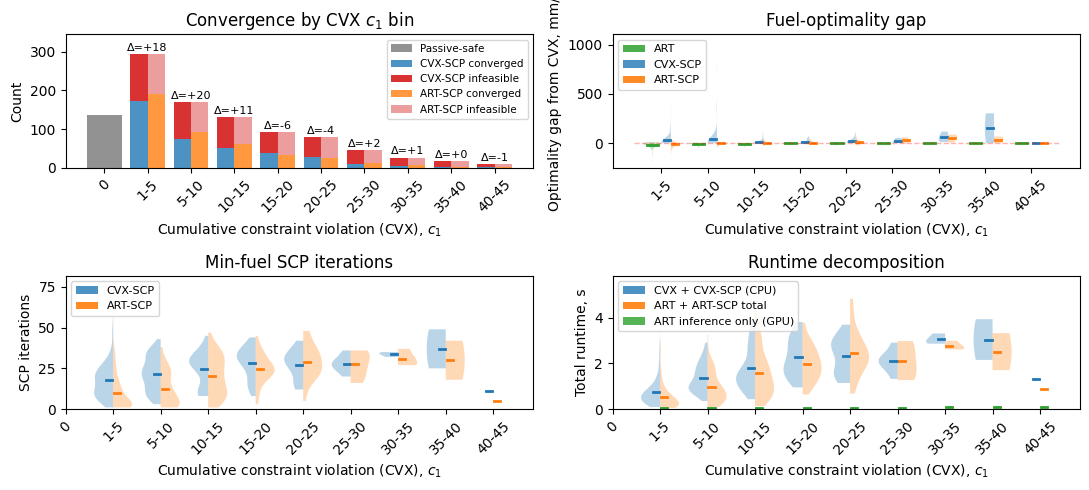

In [5]:
fig, (ax_stack, ax_gap, ax_iter, ax_runtime) = plot_cvx_art_summary(
    J_cvx=J_cvx,
    J_art=J_art,
    J_cvx_scp=J_cvx_scp,
    J_art_scp=J_art_scp,
    ctgs0=ctgs0_cvx,
    i_infeas_cvx=i_infeas_cvx,
    i_infeas_cvx_scp=i_infeas_cvx_scp,
    i_infeas_art_scp=i_infeas_art_scp,
    iter_cvx=iter_cvx,
    iter_art=iter_art,
    runtime_cvx_total=runtime_cvx_total,
    runtime_art_total=runtime_art_total,
    runtime_art_inf=runtime_art,
    ctg_min=1,
    ctg_max=45,
    step=5,
)
fig.savefig(figures_dir / 'art_ws_summary.png', dpi=300, bbox_inches='tight')


The previous behavior-wise semantic and trajectory sections were intentionally removed.
The generalized `art_01` warm-start analysis does not save command/behavior annotations,
so those old `v08` language-analysis cells are not applicable to this dataset.
